In [1]:
from importlib import reload
import os
import numpy as np
import time
from tqdm import trange
from pulsestreamer import *
from nidaqmx import *

import analysis
reload(analysis)
from analysis import *

import measurement
reload(measurement)
from measurement import *

In [111]:
# loading local pulse streamer and nidaqmx
IPaddress = findPulseStreamers(search_serial='')[0][0]
DAQ_device = nidaqmx.system.System.local().devices[0]

pulser, device_name = load_pulser_nidaq(IPaddress,DAQ_device)

Connect to Pulse Streamer via JSON-RPC.
IP / Hostname: 169.254.8.2
Pulse Streamer 8/2 firmware: v1.7.2
Client software: v1.7.0
connected NIDAQmx device name : Dev1


In [7]:
# ports of the pulse streamer for connections 
specs_ports = {'laserNum' : 1, 'gateStart' : 5, 'source' : 7}


# # Sequences 
# specs_delay = {'rising_delay' : 2,'gatelen' :  6, 'laserontime' :  31,'delay_pad' :  2,
#                'delay_shift' :  2,'gatesourcedelay' : 2}
# specs_t1 = {'rising_delay' : 20,'gatelen' : 1.5e3, 'laserontime' : 25e3,'delay_pad' : 20,
#             'delay_shift' : 50e3,'gatesourcedelay' : 5,'evolution_time' : 0.5e6}
# specs_snr = {'rising_delay' : 20,'gatelen' : 1.5e3, 'laserontime' : 20e3,'delay_pad' : 20,
#              'delay_shift' : (20e3-1.5e3)/10,'gatesourcedelay' : 5,'evolution_time' : 1.0e6}
# specs_snr_new = {'rising_delay' : 20,'gatelen' : 1.5e3, 'laserontime' : 20e3,'delay_pad' : 20,
#              'delay_shift' : (20e3-1.5e3)/10,'gatesourcedelay' : 5,'evolution_time' : 1e6}
# specs_lifetime = {'rising_delay' : 2,'gatelen' : 2, 'laserontime' : 25,'laserofftime' : 50,
#                   'delay_pad' : 2,'delay_shift' : 2,'gatesourcedelay' : 2}  
# specs_t1_ir = {'rising_delay' : 20,'gatelen' : 2e3, 'laserontime' : 25e3,'delay_pad' : 20,
#             'delay_shift' : 45e3,'gatesourcedelay' : 5,'evolution_time' : 0.45e6,'irontime' : 1e3,'irport' : 3}
# specs_t1_simple = {'rising_delay' : 10,'gatelen' : 3e3, 'laserontime' : 1000e3,'delay_pad' : 10,
#             'delay_shift' : 30e3,'gatesourcedelay' : 5,'evolution_time' : 0.30e6,'first_time': 5e3}

# Our working sequence
specs_t1_new = {'rising_delay' : 20,'gatelen' : 1e3, 'laserontime' : 50e3,'delay_pad' : 20,
            'delay_shift' : 8e3,'gatesourcedelay' : 5,'evolution_time' :400e3,'timeScaling' : 'geomspace'}

In [9]:
# experiment specifications
exp_name = "t1_new"  # write the exp_name from previous cell without the first "specs_" part 

samples = 2000
averages = 5
first_sig_ref = "signal"  # depends on the sequence 


# inside folder and file names : remember to keep 
inside_folders=['citric acid','1 mol','bigger cluster', 'p_3mW',f'l_{globals()["specs_"+exp_name]["laserontime"]/1e3}us','systematic']  
file_name=f'{globals()["specs_"+exp_name]["gatelen"]/1e3}us' # counter duration

In [11]:
# to get the total specifications of experiment and cable connections
total_specs = merge(specs_ports,globals()["specs_"+exp_name])

# # to plot sequence and getting time array
# plot_sequence(pulser=pulser,exp_name='t1_new',specifications=total_specs)
# get_time(pulser=pulser,exp_name='t1_new',specifications=total_specs)

In [836]:
# doing the measurement 
avg_data,time_axis = measure(pulser,DAQ_device,device_name,exp_name = exp_name,
                   samples=samples,averages=averages,specifications=total_specs)

number of steps : 50
Pixel : 200000
creating sequence
starting DAQ
Preparing NiDaq for the experiment
callback number in beginning: 0


  0%|          | 0/5 [00:00<?, ?it/s]

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


 20%|██        | 1/5 [00:20<01:20, 20.24s/it]

callback number after 1-th average end: 50
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


...

callback number after 3-th average end: 150
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


 80%|████████  | 4/5 [01:20<00:20, 20.23s/it]

callback number after 4-th average end: 200
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


100%|██████████| 5/5 [01:41<00:00, 20.24s/it]

callback number after 5-th average end: 250
Total Run : 250
Total Counts & Counts in one average : (1000000, 200000)
Crosscheck number of averges= 5
returning averaged counts and time_axis


In [837]:
# data saving in npz format 
dict_args = {'avg_data':avg_data,'time_axis':time_axis}  

root_directory = os.getcwd()
print(f'root directory : {root_directory}')
total_path = data_save(root_directory,inside_folders,file_name,dict_args,averages,samples)

root directory : C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes
saving data_file '[17_37_01]_1.0us.npz' is successful!



co-efficients are : [6.60806685e-01 3.07385890e-01 4.61655485e+05] 
with corresponding errorbars: [5.10470083e-02 5.06818150e-02 1.04540137e+05]

Lifetime in nano_second is : 461655.5 ± 104540.1



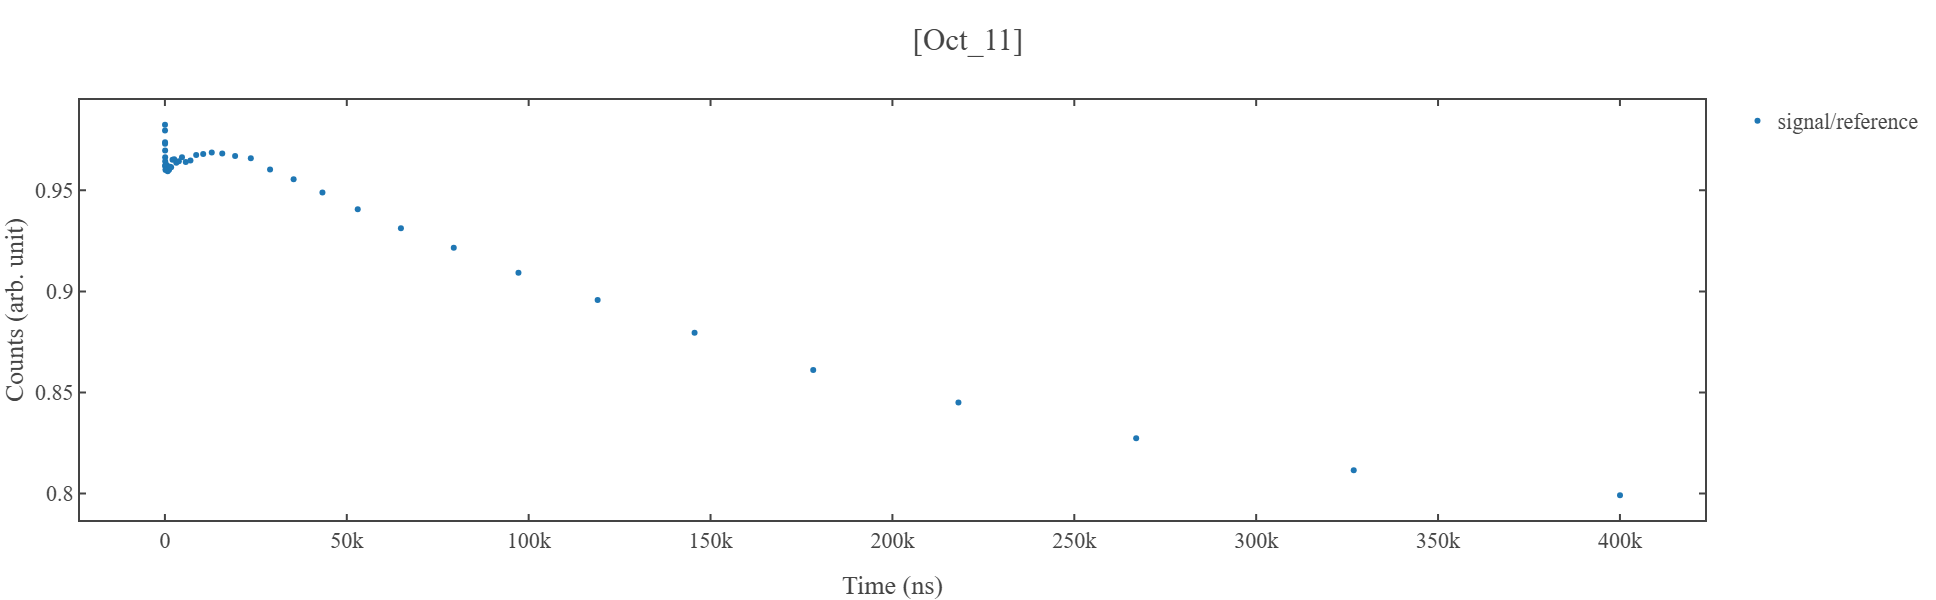

In [17]:
# loading the data 
total_path = r"C:\Users\Administrator\OneDrive\Desktop\Atanu_experiments\T1_measurements\codes\data\2025\Oct_10\first cluster\p_11mW\l_50.0us\systematic\a_5\s_2000\[11_34_11]_1.0us.npz"

load_data = dict(np.load(total_path))
time_axis,signal_photon,reference_samples,signal_samples = data_to_time_signal(load_data,samples,first=first_sig_ref)


x=time_axis[1:]
y=signal_photon[1:]
guess_parameters = np.array([0.7,1,50e3])  # input these paramters(serially) with your guess  
fitting_function = 'exp'   # y0+y_max*np.exp(-x/tau)
fitting_range = False   # for x-axis 

# fitting the data
x_fit,y_fit,coefficient,error_bars = fit_func(x,y,fit_range=fitting_range,func=fitting_function,guess_params=guess_parameters) 
if len(str(int(coefficient[2])))>7 or coefficient[2]<0:
    print('Fitted lifetime seems too long (more than 10ms) or negative.')
    print('If not expected for T1 exp, retry with increasing or decreasing the evolution time of the sequence.')
# plotting the data 
fig1 = simple_plot(x,y,show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='markers',title=f'{date}',curve_name='signal/reference')
fig2 = simple_plot(x_fit,y_fit,show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='lines',title=f'{date}',curve_name='fitted curve')
fig3 = simple_plot(x,signal_samples[1:],show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='markers',title=f'{date}',curve_name='signal')
fig4 = simple_plot(x,reference_samples[1:],show=False,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",mode='markers',title=f'{date}',curve_name='reference')

# add_figures([fig1,fig2,fig3,fig4],show=True,x_name = "Time",y_name = "Counts (T<sub>1</sub>)",title=f'[{date}]')
add_figures([fig1],show=True,x_name = "Time (ns)",y_name = "Counts (arb. unit)",title=f'[{date}]')

# Markdown cells to write specifications
> remember to change the below cells from code to markdown (see in the top).
>> Add calibrations, specifications and few reference plots.

10th April, 2025

for calibration 
laser power = 17mW (source), 200 uW(sample plane)
count =  63k/sec (bin width = 10ms, no. of bins = 1000) from emission (with 650nm LP filter)

experiment performed 
laser power = [1,3,5,7,9,11,13,15,17,18]mW (at source)
laser power = [10,30,52,76,93,109,130,152,166,174]uW (at sample plane)

laser powers = [17,15,13,11,9,7,5,3,1] mW
initialization times = [15,20,25,30,35,40,50,75,100,500,1000] us
counts = [185,175,165,150,140,130,100,70,30)] (10us)(same cluster with changed laser powers)
(for 17mW power, 185 counts was set for both the cases)
(for 17mW power, 120 counts was set for the third case)

Calibration 
laser_powers at the sample plane = [] mW

# April 15

1064 Power 
current = [1.5,2.0,2.5,3.0,3.5]
at sample plane = [0.592mW, 1.382 mW, 2.659mW, 4.3mW, 5.4mW]

975 Power 
software = [5,10,15,20,25]mW
at sample plane = [4.3,9,13.6,19,23.5]uW

525nm Power 
at source = [1,3,5,7,9,11,13,15,17]mW
at sample plane (new dichroic) = [9,24,40,59,73,85,100,116,129]uW
at sample plane (old dichroic) = [0.5,1.1,1.7,2.5,3.1,3.8,4.6,5.7,6.7]uW

# May 12

525nm Power 
at source = [1,3,5,7,9,10,11,13,15,17]mW
at sample plane (new dichroic) = [2,5.2,8,14,16,15,17,20,24,27]uW
at sample plane (old dichroic) = [0.5,1.1,1.7,2.5,3.1,3.8,4.6,5.7,6.7]uW

Counts = [65,]k

Oct 10 

525nm power at the source = 1mW 
counts = 120k (bin width = 10ms, no of bins = 1000)


Citric acid 

0.01 molar, counts 33k
0.1 molar, counts 60k (big cluster), 100k (bigger cluster), 16k (small cluster)
1 molar, counts  60k (big cluster),  120k (bigger cluster), 16k (small cluster)


power measurement

source = [1,3,4,5,7,9,11,13,15,17] mW
sample plane = [13,36,47,64,79,104,139,167,191,209] uW